---
title: "Introducción"
description: "Introducción a la inferencia causal"
categories: [Causal Inference]
order: 1
---

# Introducción


## Distinción entre Estadística Clásica e Inferencia Causal

La mayor parte de los estudios hechos con Estadística se basan en la búsqueda de métricas de asociación más que en la búsqueda de relaciones de causalidad. Un ejemplo de esta construcción de métricas es el coeficiente de correlación de Pearson o Spearman.

Estas medidas de asociación solo cuantifican cómo dos variables, digamos $X$ e $Y$, se mueven juntas — ya sea por una causa común, selección o azar — no responden a una pregunta distinta: si se interviene sobre $X$, ¿cambia $Y$ como consecuencia?

Para esto, se debe recurrir al uso de la Estadística desde otra perspectiva, la de la Inferencia Causal, ya que nos permite introducir un lenguaje formal y métodos para identificar relaciones causales, organizados en dos grandes bloques: estudios aleatorizados y estudios observacionales.

La Inferencia Causal permite identificar relaciones causales mediante la *predicción contrafactual*, es decir, estimar lo que hubiera pasado a la variable de respuesta $Y$ de unidades bajo estudio si hubiesen sido expuestas a otra condición o intervención (el contrafactual).

*Contrafactual*: Palabra que significa contrario a los hechos. En Inferencia Causal se refiere al escenario que se hubiera observado si se hubiera aplicado una intervención distinta a la que se aplicó.

## Inferencia Causal

#### Elementos necesarios

Para poder realizar el salto entre la Estadística y la Inferencia Causal es necesario establecer lo siguiente.
 - Un marco de trabajo donde se defina qué es un efecto causal bajo escenarios generales.
 - Supuestos bajo los cuales se pueda declarar o identificar causalidad.
 - Evaluar la sensibilidad de los supuestos para encontrar formas de mitigar la fuerza de estos.


### Notación

**Tratamiento**: Denotado como $Z_i$ para la unidad bajo estudio $i$ y vectorizado como $Z$ para todas las unidades, el tratamiento generalmente es un vector con entradas discretas donde cada valor se refiere a un tratamiento en específico. Por ejemplo, en un tratamiento binario, $Z_i \in \{0,1\}$, donde generalmente $1$ se refiere al tratamiento (la aplicación de una medicina en un estudio clínico, una política de reducción de tasas de interés a créditos otorgados a mujeres, etc.) y $0$ se refiere al control (la aplicación de un placebo o no aplicar ninguna política).

**Respuesta**: Usualmente se denota como $Y_i$ y se refiere a la variable de interés sobre la cuál se busca encontrar una relación causal (sobrevivencia de un paciente por la aplicación de una medicina, número de créditos otorgados a mujeres, etc.).

**Covariadas y confusores**: Las covariadas son características observadas de las unidades bajo estudio, generalmente denotadas como $X_i$ (donde $X_i$ puede ser un vector y $X$ una matriz). Un subconjunto de estas, los **confusores**, son aquellas que afectan tanto la asignación al tratamiento $Z_i$ como la variable de respuesta $Y_i$, y por ello pueden "*confundir*" el efecto causal estimado (por ejemplo, comorbilidades de los pacientes en un estudio clínico o la predisposición de las mujeres a obtener créditos en el sistema financiero formal). Cuando las covariables no son observadas, pueden denotarse como $U_i$, (por ejemplo, una covariable no observada podría ser una enfermedad no diagnosticada previa o el nivel de ingreso de las mujeres).

### Sesgos

Un problema de los estudios causales es el sesgo, el cual puede provenir de las siguientes fuentes:

 - **Confusión**: Es posible que los resultados observados sobre la variable de respuesta $Y$ no sea el resultado de la aplicación de un tratamiento, sino de las características observadas o no observadas de las unidades bajo estudio.

 - **Selección**: Es posible que la asignación de los tratamientos no provenga de un proceso de aleatorización sino por alguna regla distinta. Por ejemplo, en un estudio clínico, las unidades a las que se les asigna el tratamiento pueden ser personas "más enfermas" o que una política de reducción de tasas de interés puede asignarse a mujeres bajo la percepción de que este grupo tiene menor acceso al crédito formal, cuando en realidad esa diferencia no existe — la asignación responde a una creencia, no a un proceso aleatorizado.

 - **Medición**: Este problema ocurre cuando no es posible medir bien las características y respuestas de las unidades bajo estudio. Por ejemplo, el ingreso de un solicitante de crédito puede estar mal medido porque este pudo dar una cifra superior a la real para aumentar la probabilidad de otorgamiento. 


### Confusión

El mayor problema en la búsqueda de relaciones causales la causa la *confusión*, ya que la presencia de este fenómeno no permite distinguir adecuadamente el efecto de un tratamiento $Z_i$ sobre la variable de respuesta $Y_i$, del efecto de las covariadas $X_i$.

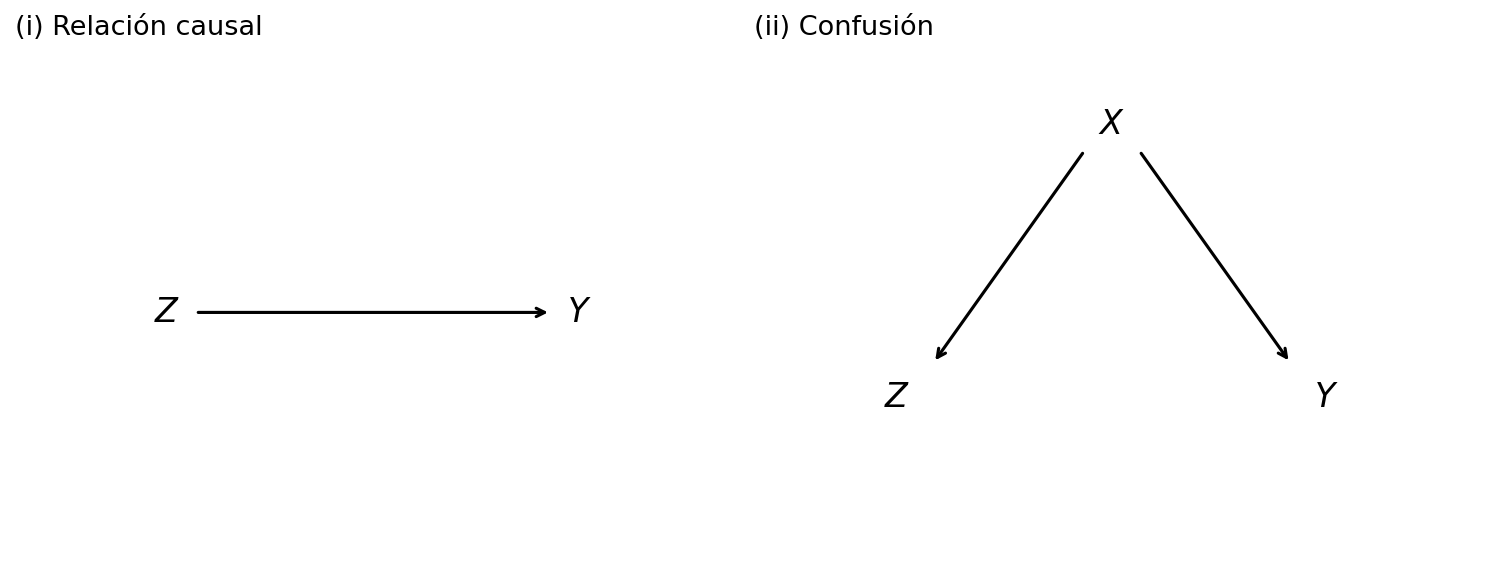


## Correlación, asociación y la paradoja de Yule-Simpson

### Medidas de asociación

 - Correlación de Pearson: Mide el grado de asociación lineal entre dos variables $X$ e $Y$:


$$\rho (X,Y) = \frac{\text{Cov}(X,Y)}{\sqrt{\text{Var}(X)\text{Var}(Y)}}$$


 - Regresión lineal simple:

$$Y = \alpha + \beta X + \epsilon$$

y puede demostrarse que $\beta$ es igual a la correlación ajustada por la desviación estándar:


$$\beta = \frac{\text{Cov}(X,Y)}{\text{Var}(X)} = \rho (X,Y)\sqrt{\frac{\text{Var}(X)}{\text{Var}(Y)}}$$


### Tablas de contingencia

Una tabla de contingencia es una tabla de frecuencias sobre dos variables de interés. Consideremos la variable de respuesta $Y \in {0,1}$ y un tratamiento binario $Z \in {0,1}$. La tabla de contingencia está dada por:

``` markdown
|       | $Y=0$    | $Y=1$    |
|-------|----------|----------|
| $Z=0$ | $p_{00}$ | $p_{01}$ |
| $Z=1$ | $p_{10}$ | $p_{11}$ |
```

Para esta tabla podemos definir tres métricas útiles:

 - Diferencia de riesgo: Es la diferencia de probabilidades condicionales de observar $Y=1$ por haber asignado el tratamiento $Z=1$ o no haberlo asignado $Z=0$.

$$RD = P(Y=1|Z=1) - P(Y=1|Z=0)= \frac{p_{11}}{p_{11}+ p_{10}} - \frac{p_{01}}{p_{01}+ p_{00}}$$

Si la diferencia es positiva, entonces es más probable observar $Y=1$ al aplicar el tratamiento $Z=1$, y si es menor, entonces al no aplicar el tratamiento ($Z=0$) hay más probabilidades de observar $Y=1$.

 - Ratio de riesgo: es el ratio de probabilidades condicionales de observar $Y=1$ dado el tratamiento ($Z=1$) o el control ($Z=0$):

$$RR = \frac{P(Y=1|Z=1)}{P(Y=1|Z=0)}= \frac{\frac{p_{11}}{p_{11}+ p_{10}}} {\frac{p_{01}}{p_{01}+ p_{00}}}$$


Si el ratio es mayor a 1, entonces bajo tratamiento es más probable observar $Y=1$ y el ratio nos dice "qué tanto" en relación con el control.

 - Razón de momios: Mide qué tan probable es observar $Y=1$ contra $Y=0$ bajo tratamiento, contra esa misma razón sin tratamiento:


$$OR = \frac{P(Y=1|Z=1)/P(Y=0|Z=1)}{P(Y=1|Z=0)/P(Y=0|Z=0)}$$


Algo que hay que notar es que si $Z$ e $Y$ son independientes, entonces $RD=0$, $RR = 1$. y $OR = 1$.

## Paradoja de Yule-Simpson

En palabras, la paradoja de Yule-Simpson es una situación que se presenta cuando una relación global entre dos variables cambia de dirección  cuando se tiene en consideración una segmentación por una tercera variable. 

### Confusión

La paradoja de Yule-Simpson puede observarse por confusión, es decir, que una covariable puede afectar al tratamiento y a la respuesta. Por ejemplo, digamos que se quiere investigar el efecto del tamaño del comercio (pequeño o grande) en la tasa de aceptación de pagos con tarjeta (es decir, que la tarjeta sea aceptada o rechazada), medida en miles de operaciones. 

Para este análisis, se crea la siguiente tabla de contingencia:

``` markdown
|          | Completas | Rechazadas | Total | Tasa |
|----------|-----------|------------|-------|------|
| Pequeño  | 98        | 12         | 110   | 89%  |
| Grande   | 180       | 40         | 220   | 82%  |
```
De dicha tabla se concluye que la tasa de aceptación es peor en grandes comercios. 


Sin embargo, podemos agregar como confusor el tipo de tarjeta (crédito o débito): se realizan más operaciones de débito en comercios pequeños y más operaciones de tarjeta de crédito en comercios grandes. De esta forma obtenemos dos tablas de contingencia distintas por tipo de tarjeta:

Débito

``` markdown
|          | Completas | Rechazadas | Total | Tasa |
|----------|-----------|------------|-------|------|
| Pequeño  | 90        | 10         | 100   | 90%  |
| Grande   | 18        | 2          | 20    | 90%  |
```
Crédito

``` markdown
|          | Completas | Rechazadas | Total | Tasa |
|----------|-----------|------------|-------|------|
| Pequeño  | 8         | 2          | 10    | 80%  |
| Grande   | 162       | 38         | 200   | 81%  |
```

En ambas tablas puede observarse que la tasa de aceptación es mayor en comercios grandes, por lo que el efecto del tratamiento (tamaño del comercio) se invierte.

En el caso global existe *confusión*, ya que el tipo de tarjeta afecta al número de operaciones hechas en cada tipo de comercio (más débito en comercios pequeños y más crédito en comercios grandes). De esta forma, no es posible distinguir el efecto del tratamiento (tamaño del comercio) sobre la respuesta (tasa de aceptación) por el efecto de una variable adicional (tipo de tarjeta).

De esta forma, si definimos $X \in \{1=\text{ débito}, 0=\text{ crédito}\}$, $Z \in \{1=\text{ comercio grande}, 0=\text{ comercio chico}\}$ y $Y \in \{1=\text{ Completas}, 0=\text{ Rechazadas}\}$, podemos definir un grafo de la siguiente forma:

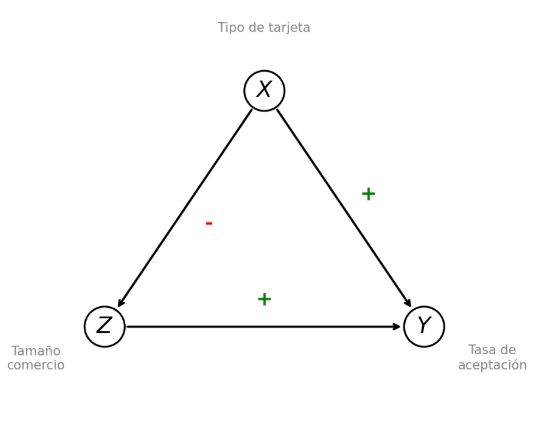

### Mediación

Ahora pensemos en una situación como la siguiente:

El gobierno busca incrementar el número de créditos otorgados a mujeres mediante una política pública de topar las tasas de interés de tarjetas de crédito otorgadas a mujeres a tres puntos porcentuales menor que la de tarjetas de crédito otorgadas a hombres.  

Sin embargo, es posible que esta política tenga un efecto sobre el score crediticio de las mujeres, ya que con una menor tasa, las mujeres pagan menos intereses y, con esto, tienen que realizar pagos más pequeños, reduciendo su probabilidad de impago. Esta mejora del score crediticio puede provocar que las instituciones financieras quieran ofrecer más créditos a mujeres. 

En este caso, el efecto del tratamiento (la reducción de la tasa de interés) sobre la respuesta (el número de tarjetas de crédito otorgadas a mujeres), puede descomponerse en dos, en un efecto directo y un efecto indirecto de la mejora del score crediticio que a su vez tiene un efecto sobre el número de tarjetas de crédito.

En este caso, el tratamiento $Z$ tiene un efecto sobre la covariable $X$ y la respuesta $Y$. En esta situación, $X$ se denomina *mediador*.

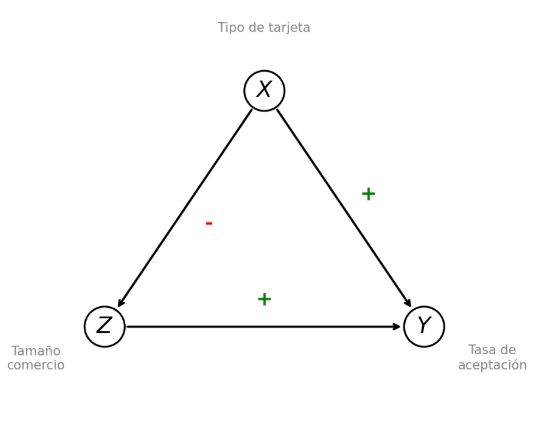

## Marcos de trabajo de inferencia causal

Los dos marcos de trabajo más utilizados en Inferencia Causal son el marco de *resultados potenciales* y el marco de *diagramas causales*.

El método que mayormente se utiliza en estos notebooks es el de resultados potenciales por lo que se recomienda ver esos notebooks para mayores referencias.


### Diagramas causales (pendiente)
